# minimal-linop 3/3: Benchmark

What the abstraction costs: the overhead against hand-written torch, `LinOpPatch` against its definition, batching, `to_matrix`, precision, and when not to use it.

Series: [1. Why](01_why_linear_operators.ipynb) · [2. What it computes](02_what_it_computes.ipynb) · [3. Benchmark](03_benchmark.ipynb)

In [1]:
import math, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from minimal_linop import (LinOpIdentity, LinOpFft, LinOpMul, LinOpCrop, LinOpRoll,
                           patch_by_crop_and_roll, LinOpPatch, LinOpCat, adjoint_error, operator_norm, to_matrix)

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.2),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 1.5,
    "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]),
    "image.cmap": "gray",
})
torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.14.0


Every timing below comes from one machine and one process. They indicate the shape of the scaling on this machine and are not portable constants.

In [2]:
import os, platform

print(f"processor       {platform.processor()} / {platform.machine()}")
print(f"logical cores   {os.cpu_count()}")
print(f"torch threads   {torch.get_num_threads()}")
print(f"MPS available   {torch.backends.mps.is_available()}")
print("\nTimings are indicative for this machine only.")

processor       arm / arm64
logical cores   8
torch threads   4
MPS available   True

Timings are indicative for this machine only.


## Timing protocol

`bench` makes one warm-up call (allocations, the FFT plan cache and, for `LinOpPatch`, moving its index tables to the device), then `repeats` timed calls, and returns the median. Calls on MPS are asynchronous, so they are bracketed with `torch.mps.synchronize()`.

Colours are fixed throughout: blue is hand-written `torch`, orange the operator, aqua the cheaper of two operators compared, yellow MPS.

In [3]:
BLUE, ORANGE, AQUA, YELLOW, PINK = plt.rcParams["axes.prop_cycle"].by_key()["color"]
C64, C128 = torch.complex64, torch.complex128


def bench(fn, repeats=7):
    """One warm-up call, then `repeats` timed calls; the median, in seconds."""
    out = fn()
    on_mps = torch.is_tensor(out) and out.device.type == "mps"
    if on_mps:
        torch.mps.synchronize()
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        if on_mps:
            torch.mps.synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


z256 = torch.randn(256, 256, dtype=C64)
print(f"bench(lambda: torch.fft.fft2(z256)) = {1e6 * bench(lambda: torch.fft.fft2(z256)):.1f} us"
      f"   [{z256.shape[0]}x{z256.shape[1]} complex64, the unit of comparison below]")

bench(lambda: torch.fft.fft2(z256)) = 277.4 us   [256x256 complex64, the unit of comparison below]


# Part A. What the algebra costs

## A.1 A composed operator against the same lines written by hand

The forward model of notebook 1 for one scan position,

$$A x = \mathcal{F}\big[\, p \odot (\text{window of } x)\,\big],$$

as `LinOpFft(dim=(-2,-1)) @ LinOpMul(probe) @ LinOpPatch(...)`, against a function that does the same three things with `torch` calls and precomputed indices. The difference is the price of the abstraction: three Python method calls and a few attribute lookups per application.

In [4]:
PATCH = 32
probe = torch.randn(PATCH, PATCH, dtype=C64)
sizes_ov = [64, 128, 256, 512, 1024, 2048]
t_op, t_hand, t_opT, t_handT = [], [], [], []

print(f"{'object':>10} {'apply (op)':>13} {'apply (hand)':>15} {'applyT (op)':>14} "
      f"{'applyT (hand)':>16}")
for n in sizes_ov:
    x, y = torch.randn(n, n, dtype=C64), torch.randn(PATCH, PATCH, dtype=C64)
    A = LinOpFft(dim=(-2, -1)) @ LinOpMul(probe) @ LinOpPatch((n, n), (PATCH, PATCH), shifts=(5, -7))

    start = n // 2 - PATCH // 2                       # the same window, precomputed
    iy = torch.remainder(torch.arange(start, start + PATCH) - 5, n)[:, None]
    ix = torch.remainder(torch.arange(start, start + PATCH) + 7, n)[None, :]
    flat = (iy * n + ix).reshape(-1)

    def hand(x=x, iy=iy, ix=ix):
        return torch.fft.fft2(probe * x[..., iy, ix], norm="ortho")

    def handT(y=y, flat=flat, n=n):
        v = probe.conj() * torch.fft.ifft2(y, norm="ortho")
        return torch.zeros(n * n, dtype=C64).scatter_add(-1, flat, v.reshape(-1)).reshape(n, n)

    assert torch.allclose(A.apply(x), hand(), atol=1e-5)
    assert torch.allclose(A.applyT(y), handT(), atol=1e-5)
    # Two benches, faster kept: the adjoints allocate an object-sized tensor
    # every call, and whichever contender runs first pays for the fresh pages.
    fair = lambda f: min(bench(f), bench(f))
    t_op.append(fair(lambda: A.apply(x)))
    t_hand.append(fair(hand))
    t_opT.append(fair(lambda: A.applyT(y)))
    t_handT.append(fair(handT))
    print(f"{f'{n}x{n}':>10} {1e6*t_op[-1]:>10.1f} us {1e6*t_hand[-1]:>12.1f} us "
          f"{1e6*t_opT[-1]:>11.1f} us {1e6*t_handT[-1]:>13.1f} us")

    object    apply (op)    apply (hand)    applyT (op)    applyT (hand)
     64x64       16.9 us         15.6 us        29.4 us          18.9 us
   128x128       16.9 us         15.8 us        32.6 us          22.4 us
   256x256       17.3 us         16.2 us        63.0 us          50.0 us
   512x512       16.8 us         15.7 us       184.3 us         154.0 us
 1024x1024       17.0 us         16.0 us       856.6 us         656.8 us


 2048x2048       17.3 us         16.0 us      3266.8 us        3524.6 us


The overhead of a chain does not depend on the size of the data, so we measure it alone: a chain of $k$ `LinOpIdentity` operators applied to a single number is pure dispatch.

 nodes       time
     1    0.25 us
     2    0.38 us
     4    0.54 us
     8    0.83 us
    16    1.46 us
    32    2.75 us

marginal cost of one more operator in a chain: 81 ns


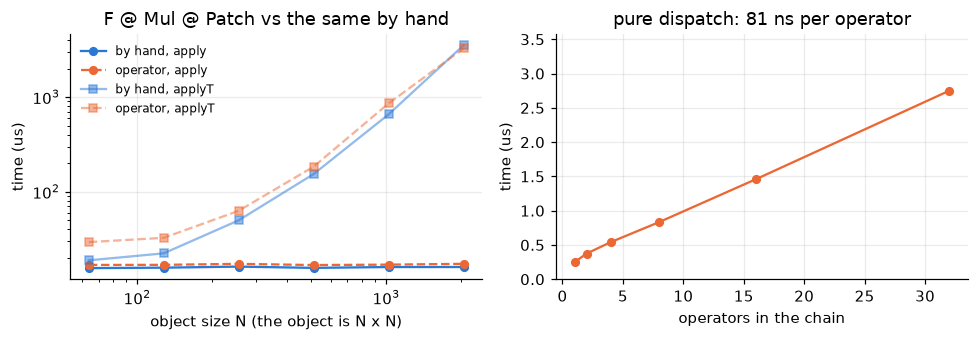

In [5]:
depths = [1, 2, 4, 8, 16, 32]
t_chain = []
one = torch.zeros(1)
for k in depths:
    chain = LinOpIdentity()
    for _ in range(k - 1):
        chain = chain @ LinOpIdentity()
    t_chain.append(bench(lambda: chain.apply(one), repeats=31))
per_node = 1e9 * (t_chain[-1] - t_chain[0]) / (depths[-1] - depths[0])
print(f"{'nodes':>6} {'time':>10}")
for k, t in zip(depths, t_chain):
    print(f"{k:>6} {1e6*t:>7.2f} us")
print(f"\nmarginal cost of one more operator in a chain: {per_node:.0f} ns")

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))
ax.loglog(sizes_ov, 1e6 * np.array(t_hand), "o-", ms=5, color=BLUE, label="by hand, apply")
ax.loglog(sizes_ov, 1e6 * np.array(t_op), "o--", ms=5, color=ORANGE, label="operator, apply")
ax.loglog(sizes_ov, 1e6 * np.array(t_handT), "s-", ms=5, color=BLUE, alpha=0.5, label="by hand, applyT")
ax.loglog(sizes_ov, 1e6 * np.array(t_opT), "s--", ms=5, color=ORANGE, alpha=0.5, label="operator, applyT")
ax.set(xlabel="object size N (the object is N x N)", ylabel="time (us)",
       title="F @ Mul @ Patch vs the same by hand")
ax.legend(frameon=False, fontsize=8, loc="upper left")

ax2.plot(depths, 1e6 * np.array(t_chain), "o-", ms=5, color=ORANGE)
ax2.set(xlabel="operators in the chain", ylabel="time (us)",
        title=f"pure dispatch: {per_node:.0f} ns per operator", ylim=(0, 1.3 * 1e6 * max(t_chain)))
fig.tight_layout()
plt.show()

The forward curves lie on top of each other. In this run the hand-written function takes about 16 us from $64^2$ to $2048^2$ and the composed operator about a microsecond more (1.13 us at $256^2$ in the summary at the end), whatever the size of the object, because both end in the same three `torch` kernels. The adjoints grow with the object, since both return an object-sized tensor. At small sizes the operator is the slower of the two, 29.4 us against 18.9 us at $64^2$. At large sizes allocating and zeroing the output dominates both and the order is not settled: the operator takes 856.6 us against 656.8 us at $1024^2$, and 3266.8 us against 3524.6 us at $2048^2$.

The marginal cost of one more operator in a chain is of the order of a hundred nanoseconds, 81 ns in this run. It matters only when the kernels themselves take a microsecond, which C.1 measures.

## A.2 `LinOpPatch` against its definition

`LinOpPatch(in_shape, out_shape, shifts)` is defined as `patch_by_crop_and_roll`, a `LinOpCrop @ LinOpRoll` composition (notebook 2 checks that they agree bit for bit), but it gathers the window directly instead of rolling the whole object. The forward direction is then O(patch) whatever the object size. The adjoint still returns an object-sized tensor, so it cannot beat O(object), but it writes only the patch into it.

In [6]:
sizes_p = [64, 128, 256, 512, 1024, 2048, 4096]
t_patch, t_roll, t_patchT, t_rollT = [], [], [], []
print(f"{'object':>11} {'patch.apply':>13} {'definition':>12} {'speed-up':>9} "
      f"{'patch.applyT':>14} {'definition':>12} {'speed-up':>9}")
for n in sizes_p:
    x, y = torch.randn(n, n, dtype=C64), torch.randn(PATCH, PATCH, dtype=C64)
    fast = LinOpPatch((n, n), (PATCH, PATCH), shifts=(5, -7))
    slow = patch_by_crop_and_roll((n, n), (PATCH, PATCH), shifts=(5, -7))
    reps = 7 if n <= 1024 else 3
    t_patch.append(bench(lambda: fast.apply(x), reps))
    t_roll.append(bench(lambda: slow.apply(x), reps))
    t_patchT.append(bench(lambda: fast.applyT(y), reps))
    t_rollT.append(bench(lambda: slow.applyT(y), reps))
    print(f"{f'{n}x{n}':>11} {1e6*t_patch[-1]:>10.1f} us {1e6*t_roll[-1]:>9.1f} us "
          f"{t_roll[-1]/t_patch[-1]:>9.1f} {1e6*t_patchT[-1]:>11.1f} us "
          f"{1e6*t_rollT[-1]:>9.1f} us {t_rollT[-1]/t_patchT[-1]:>9.1f}")

     object   patch.apply   definition  speed-up   patch.applyT   definition  speed-up
      64x64        8.5 us      14.0 us       1.6        18.2 us      22.4 us       1.2
    128x128        8.1 us      18.7 us       2.3        23.6 us      29.3 us       1.2
    256x256        8.0 us      56.0 us       7.0        52.3 us      97.0 us       1.9
    512x512        8.3 us     168.0 us      20.3       157.3 us     398.9 us       2.5
  1024x1024        8.5 us     894.2 us     105.2       715.6 us    1801.5 us       2.5


  2048x2048        9.0 us    3298.9 us     366.5      2943.3 us    7442.1 us       2.5


  4096x4096        9.4 us   14203.4 us    1515.0     13550.2 us   25014.3 us       1.8


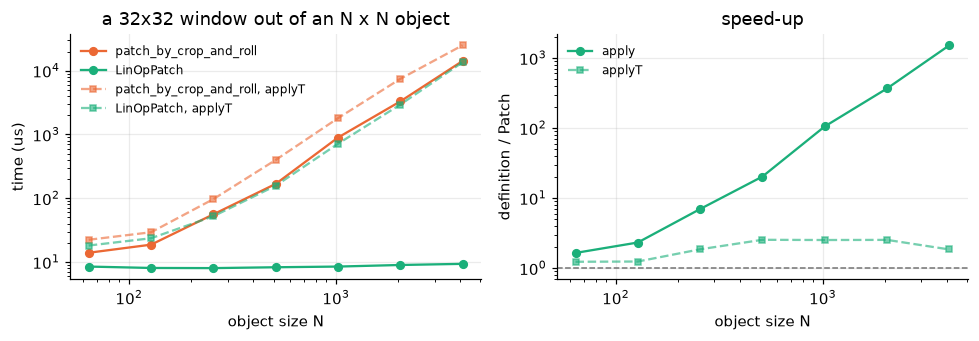

In [7]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))
ax.loglog(sizes_p, 1e6 * np.array(t_roll), "o-", ms=5, color=ORANGE, label="patch_by_crop_and_roll")
ax.loglog(sizes_p, 1e6 * np.array(t_patch), "o-", ms=5, color=AQUA, label="LinOpPatch")
ax.loglog(sizes_p, 1e6 * np.array(t_rollT), "s--", ms=4, color=ORANGE, alpha=0.6,
          label="patch_by_crop_and_roll, applyT")
ax.loglog(sizes_p, 1e6 * np.array(t_patchT), "s--", ms=4, color=AQUA, alpha=0.6,
          label="LinOpPatch, applyT")
ax.set(xlabel="object size N", ylabel="time (us)", title=f"a {PATCH}x{PATCH} window out of an N x N object")
ax.legend(frameon=False, fontsize=8, loc="upper left")

ax2.semilogx(sizes_p, np.array(t_roll) / np.array(t_patch), "o-", ms=5, color=AQUA, label="apply")
ax2.semilogx(sizes_p, np.array(t_rollT) / np.array(t_patchT), "s--", ms=4, color=AQUA, alpha=0.6,
             label="applyT")
ax2.axhline(1.0, color="0.45", lw=1, ls="--")
ax2.set(xlabel="object size N", ylabel="definition / Patch", title="speed-up", yscale="log")
ax2.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

The forward direction is flat, between 8.0 and 9.4 us in this run from a $64^2$ object to a $4096^2$ one, because it reads $32^2$ samples either way, while the definition copies the object and grows as $N^2$. The adjoints differ by a factor between 1.2 and 2.5 in this run: both produce an $N \times N$ tensor and the zeroing of that tensor is what both pay for. For a ptychographic model with thousands of positions the forward saving is large.

## A.3 Batching

Batch axes are leading axes, so a batch is one call on a tensor with one more dimension. The kernels amortise their launch overhead over the batch: the time per object falls as the batch grows and then levels off, from 59.0 us alone to between 20.6 and 24.0 us from $B = 16$ on in the run below.

    B       total    per object
    1     0.06 ms       59.0 us
    2     0.08 ms       40.4 us
    4     0.15 ms       37.8 us
    8     0.26 ms       32.8 us
   16     0.38 ms       24.0 us
   32     0.75 ms       23.5 us
   64     1.32 ms       20.6 us
  128     3.00 ms       23.4 us

per-object cost at B = 128, relative to B = 1: 0.40x


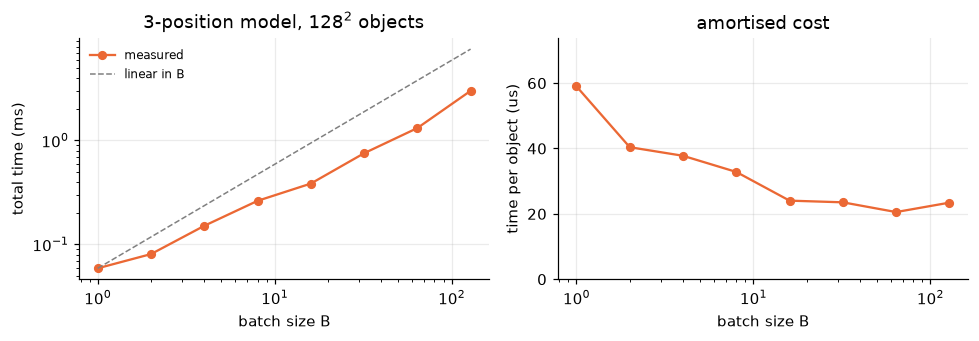

In [8]:
N_BATCH = 128
model = LinOpCat([LinOpFft(dim=(-2, -1)) @ LinOpMul(probe) @ LinOpPatch((N_BATCH, N_BATCH), (PATCH, PATCH),
                                                                       shifts=(s, -s))
                  for s in (-32, 0, 32)])
batches = [1, 2, 4, 8, 16, 32, 64, 128]
t_b = []
print(f"{'B':>5} {'total':>11} {'per object':>13}")
for B in batches:
    xb = torch.randn(B, N_BATCH, N_BATCH, dtype=C64)
    t_b.append(bench(lambda: model.apply(xb), repeats=5))
    print(f"{B:>5} {1e3*t_b[-1]:>8.2f} ms {1e6*t_b[-1]/B:>10.1f} us")
print(f"\nper-object cost at B = {batches[-1]}, relative to B = 1: "
      f"{(t_b[-1]/batches[-1])/t_b[0]:.2f}x")

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))
ax.loglog(batches, 1e3 * np.array(t_b), "o-", ms=5, color=ORANGE, label="measured")
ax.loglog(batches, 1e3 * t_b[0] * np.array(batches), "--", color="0.5", lw=1, label="linear in B")
ax.set(xlabel="batch size B", ylabel="total time (ms)", title="3-position model, $128^2$ objects")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax2.semilogx(batches, 1e6 * np.array(t_b) / np.array(batches), "o-", ms=5, color=ORANGE)
ax2.set(xlabel="batch size B", ylabel="time per object (us)", title="amortised cost",
        ylim=(0, 1.25e6 * max(np.array(t_b) / np.array(batches))))
fig.tight_layout()
plt.show()

## A.4 What `to_matrix` costs

`to_matrix(A)` applies the operator to the $n$ basis vectors of its input space in one batched call. Time grows as $n$ times the cost of $A$ and memory as $n \times m$; for a 2-D operator on an $n \times n$ image that is $n^4$ entries. It is a debugging tool, and the table says where it stops being one.

    image         matrix      memory        time
      4x4        16 x 16     0.00 MiB     0.02 ms
      8x8        64 x 64     0.03 MiB     0.05 ms
    12x12      144 x 144     0.16 MiB     0.15 ms
    16x16      256 x 256     0.50 MiB     0.43 ms
    24x24      576 x 576     2.53 MiB     2.04 ms
    32x32    1024 x 1024     8.00 MiB     6.08 ms
    48x48    2304 x 2304    40.50 MiB    31.13 ms
    64x64    4096 x 4096      0.1 GiB   (do not)
  128x128  16384 x 16384      2.0 GiB   (do not)
  256x256  65536 x 65536     32.0 GiB   (do not)


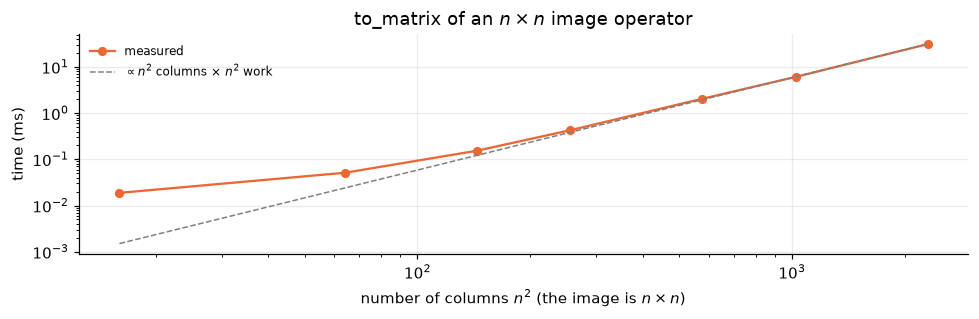

In [9]:
sizes_m = [4, 8, 12, 16, 24, 32, 48]
t_mat, mem_mat = [], []
print(f"{'image':>9} {'matrix':>14} {'memory':>11} {'time':>11}")
for n in sizes_m:
    Am = LinOpFft(dim=(-2, -1)) @ LinOpMul(torch.randn(n, n, dtype=C64))
    t_mat.append(bench(lambda: to_matrix(Am, in_shape=(n, n)), repeats=3))
    mem_mat.append((n * n) ** 2 * 8 / 2 ** 20)
    print(f"{f'{n}x{n}':>9} {f'{n*n} x {n*n}':>14} {mem_mat[-1]:>8.2f} MiB {1e3*t_mat[-1]:>8.2f} ms")
for n in (64, 128, 256):
    print(f"{f'{n}x{n}':>9} {f'{n*n} x {n*n}':>14} {(n*n)**2*8/2**30:>8.1f} GiB   (do not)")

fig, ax = plt.subplots(figsize=(9, 3.0))
ax.loglog(np.array(sizes_m) ** 2, 1e3 * np.array(t_mat), "o-", ms=5, color=ORANGE, label="measured")
ref = 1e3 * t_mat[-1] * (np.array(sizes_m) ** 2 / sizes_m[-1] ** 2) ** 2
ax.loglog(np.array(sizes_m) ** 2, ref, "--", color="0.5", lw=1, label="$\\propto n^2$ columns $\\times$ $n^2$ work")
ax.set(xlabel="number of columns $n^2$ (the image is $n \\times n$)", ylabel="time (ms)",
       title="to_matrix of an $n \\times n$ image operator")
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

## A.5 MPS

The operators hold no device: the coefficients passed in and the tensor they are applied to decide where the work happens. The same model, CPU against Metal, in complex64.

  128x128   CPU    0.11 ms   MPS    0.48 ms   speed-up  0.24   max |cpu - mps| = 1.03e-06
  256x256   CPU    0.40 ms   MPS    0.65 ms   speed-up  0.62   max |cpu - mps| = 1.24e-06
  512x512   CPU    1.78 ms   MPS    1.14 ms   speed-up  1.55   max |cpu - mps| = 2.31e-06


 1024x1024  CPU    9.06 ms   MPS    2.00 ms   speed-up  4.53   max |cpu - mps| = 1.70e-06

adjoint_error on MPS: 2.33e-10


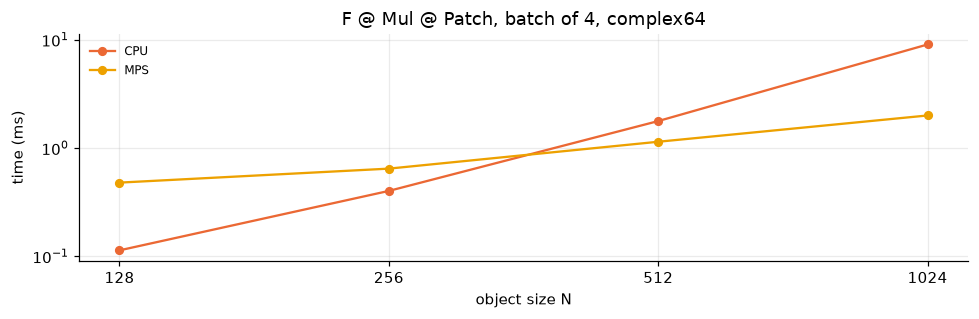

In [10]:
mps_sizes, t_cpu_d, t_mps_d = [], [], []
if torch.backends.mps.is_available():
    try:
        for n in [128, 256, 512, 1024]:
            p_cpu = torch.randn(n // 2, n // 2, dtype=C64)
            chain = lambda p, n=n: (LinOpFft(dim=(-2, -1)) @ LinOpMul(p)
                                    @ LinOpPatch((n, n), (n // 2, n // 2), shifts=(5, -7)))
            A_cpu, A_mps = chain(p_cpu), chain(p_cpu.to("mps"))
            xc = torch.randn(4, n, n, dtype=C64)
            xm = xc.to("mps")
            torch.mps.synchronize()
            tc, tg = bench(lambda: A_cpu.apply(xc), 5), bench(lambda: A_mps.apply(xm), 5)
            e = (A_cpu.apply(xc) - A_mps.apply(xm).cpu()).abs().max().item()
            mps_sizes.append(n); t_cpu_d.append(tc); t_mps_d.append(tg)
            print(f"{n:>5}x{n:<5} CPU {1e3*tc:>7.2f} ms   MPS {1e3*tg:>7.2f} ms   "
                  f"speed-up {tc/tg:>5.2f}   max |cpu - mps| = {e:.2e}")
        print(f"\nadjoint_error on MPS: "
              f"{adjoint_error(A_mps, xm, torch.randn(4, 512, 512, dtype=C64).to('mps')):.2e}")
    except Exception as exc:                          # pragma: no cover - device dependent
        print("MPS run failed:", type(exc).__name__, exc)
else:
    print("MPS is not available on this machine.")

if mps_sizes:
    fig, ax = plt.subplots(figsize=(9, 3.0))
    ax.loglog(mps_sizes, 1e3 * np.array(t_cpu_d), "o-", ms=5, color=ORANGE, label="CPU")
    ax.loglog(mps_sizes, 1e3 * np.array(t_mps_d), "o-", ms=5, color=YELLOW, label="MPS")
    ax.set(xlabel="object size N", ylabel="time (ms)", title="F @ Mul @ Patch, batch of 4, complex64")
    ax.set_xticks(mps_sizes, [str(v) for v in mps_sizes])
    ax.minorticks_off()
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    fig.tight_layout()
    plt.show()

# Part B. Precision

## B.1 How exact is exact

The identity $\langle Ax, y\rangle = \langle x, A^H y\rangle$ holds for the mathematical operator; the code is subject to round-off, so `adjoint_error` returns a small number rather than zero. Below, the composed model in complex64 and complex128 against size, the worst of five random draws per point.

The error falls with $N$: the two sums run over the $N^2$ samples of the window, so the discrepancy accumulates like $N\,\varepsilon$ while the denominator $\lVert Ax\rVert\lVert y\rVert$ grows like $N^2$, and the ratio goes roughly as $\varepsilon/N$, the slope of the dotted line. What matters is the gap between the two dtypes, the ratio $\varepsilon_{32}/\varepsilon_{64}$, and that neither drifts with size.

     N    complex64    complex128
    16     8.90e-09      2.89e-17
    32     5.45e-09      7.08e-18
    64     5.49e-09      8.76e-18
   128     3.30e-09      6.92e-18


   256     6.97e-10      1.30e-18


   512     5.84e-10      1.30e-18


  1024     2.33e-10      4.33e-19

ratio, median over the sweep: 5.4e+08   (eps32 / eps64 = 5.4e+08)
worst over the sweep: complex64 8.9e-09, complex128 2.9e-17


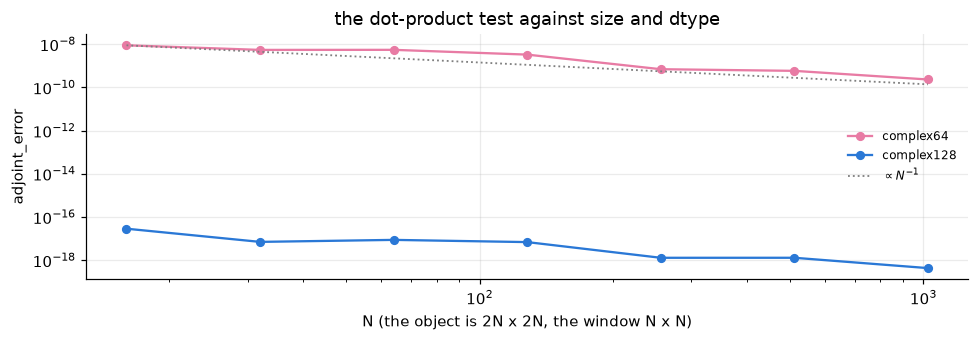

In [11]:
sizes_e = [16, 32, 64, 128, 256, 512, 1024]
e32, e64 = [], []
print(f"{'N':>6} {'complex64':>12} {'complex128':>13}")
for n in sizes_e:
    row = []
    for dtype in (C64, C128):
        Ae = (LinOpFft(dim=(-2, -1)) @ LinOpMul(torch.randn(n, n, dtype=dtype))
              @ LinOpCrop((2 * n, 2 * n), (n, n)))
        row.append(max(adjoint_error(Ae, torch.randn(2 * n, 2 * n, dtype=dtype),
                                     torch.randn(n, n, dtype=dtype)) for _ in range(5)))
    e32.append(row[0]); e64.append(row[1])
    print(f"{n:>6} {row[0]:>12.2e} {row[1]:>13.2e}")
print(f"\nratio, median over the sweep: {np.median(np.array(e32) / np.array(e64)):.1e}"
      f"   (eps32 / eps64 = {np.finfo(np.float32).eps / np.finfo(np.float64).eps:.1e})")
print(f"worst over the sweep: complex64 {max(e32):.1e}, complex128 {max(e64):.1e}")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.loglog(sizes_e, e32, "o-", ms=5, color=PINK, label="complex64")
ax.loglog(sizes_e, e64, "o-", ms=5, color=BLUE, label="complex128")
ax.loglog(sizes_e, np.array(e32)[0] * (np.array(sizes_e) / sizes_e[0]) ** -1.0, ":", color="0.5",
          lw=1.2, label=r"$\propto N^{-1}$")
ax.set(xlabel="N (the object is 2N x 2N, the window N x N)",
       ylabel="adjoint_error", title="the dot-product test against size and dtype")
ax.legend(frameon=False, fontsize=8, loc="center right", ncols=1)
fig.tight_layout()
plt.show()

## B.2 Where float32 is not enough

An exact adjoint does not make a solver exact. The gradient iteration of notebook 1, run in both precisions with the step $1/\lVert A\rVert^2$ from `operator_norm`, stalls when the residual reaches the round-off floor of its dtype. The two runs are otherwise identical; the printed timings give the cost of float64 on this machine.

In [12]:
n, WIN = 64, 24
shifts_b = [(sy, sx) for sy in (-24, -8, 8, 24) for sx in (-24, -8, 8, 24)]
gp = torch.arange(WIN, dtype=torch.float64) - WIN // 2
r2 = (gp[:, None] ** 2 + gp[None, :] ** 2) / (WIN / 2) ** 2
probe_b = torch.exp(-1.5 * r2 ** 2) * torch.exp(1j * 5.0 * r2)      # the probe of notebook 1

print(f"{'dtype':>12} {'20 it.':>10} {'40 it.':>10} {'150 it.':>10} {'error on x':>12} {'time':>9}")
for dtype in (C64, C128):
    Ab = LinOpCat([LinOpFft(dim=(-2, -1)) @ LinOpMul(probe_b.to(dtype))
                   @ LinOpPatch((n, n), (WIN, WIN), shifts=s) for s in shifts_b])
    x_true = torch.randn(n, n, dtype=dtype)
    bb = Ab @ x_true
    tau_b = 1.0 / operator_norm(Ab, torch.randn(n, n, dtype=dtype), n_iter=60) ** 2
    scale = float((bb.abs() ** 2).sum())
    xx, hist = torch.zeros(n, n, dtype=dtype), []
    t0 = time.perf_counter()
    for _ in range(150):
        r = Ab @ xx - bb
        hist.append(float((r.abs() ** 2).sum()) / scale)
        xx = xx - tau_b * (Ab.H @ r)
    dt = time.perf_counter() - t0
    print(f"{str(dtype).split('.')[-1]:>12} {hist[20]:>10.1e} {hist[40]:>10.1e} {hist[-1]:>10.1e} "
          f"{float((xx - x_true).norm() / x_true.norm()):>12.1e} {1e3*dt:>6.0f} ms")

       dtype     20 it.     40 it.    150 it.   error on x      time


   complex64    1.5e-10    1.7e-14    1.7e-14      9.7e-08    132 ms


  complex128    1.3e-10    4.0e-18    6.1e-32      1.8e-16    158 ms


# Part C. When not to use it

## C.1 When the arrays are tiny

The dispatch cost measured in A.1 is small next to a $64^2$ FFT and is not small next to a $4 \times 4$ one. Below, the same chain on a shrinking problem: from $64 \times 64$ down to $4 \times 4$ the overhead stays between 1.25 and 1.62 us in this run and its share of the time grows from 6.5% to 19.6%. The $128 \times 128$ row is higher (7.04 us, 7.8%) and does not follow that trend. Wrapping a handful of numbers in an operator tree inside an inner loop buys nothing.

In [13]:
print(f"{'window':>8} {'operator':>11} {'by hand':>11} {'overhead':>11} {'share':>8}")
for m in (4, 8, 16, 32, 64, 128):
    p = torch.randn(m, m, dtype=C64)
    Ac = LinOpFft(dim=(-2, -1)) @ LinOpMul(p) @ LinOpCrop((2 * m, 2 * m), (m, m))
    xc = torch.randn(2 * m, 2 * m, dtype=C64)
    lo = m // 2
    handc = lambda: torch.fft.fft2(p * xc[lo:lo + m, lo:lo + m], norm="ortho")
    to, th = bench(lambda: Ac.apply(xc), 21), bench(handc, 21)
    print(f"{f'{m}x{m}':>8} {1e6*to:>8.2f} us {1e6*th:>8.2f} us {1e6*(to-th):>+8.2f} us "
          f"{100*(to-th)/to:>7.1f}%")

  window    operator     by hand    overhead    share
     4x4     8.29 us     6.67 us    +1.62 us    19.6%
     8x8     8.42 us     6.92 us    +1.50 us    17.8%
   16x16     9.42 us     8.17 us    +1.25 us    13.3%
   32x32    11.92 us    10.62 us    +1.29 us    10.8%
   64x64    24.29 us    22.71 us    +1.58 us     6.5%
 128x128    89.92 us    82.88 us    +7.04 us     7.8%


## C.2 The other limits

* A dense matrix that fits in memory is better used as a tensor. `LinOpMatrix` lets a measurement matrix join a chain; for a plain matrix-vector product, write `M @ x`.
* `to_matrix` costs $n$ applications of $A$ in time and $n m$ entries in memory. A.4 gives the numbers; use it on a shrunken version of the operator.
* `operator_norm` costs `n_iter` forward and adjoint applications and converges from below. For a step size, compute it once and keep a margin.
* `LinOpCat` concatenates along the last axis only. A model with heterogeneous outputs has to flatten them into that axis, with `LinOpFunction` if needed.
* Nothing here is nonlinear. $y = |Ax|^2$ is not a `LinOp`; it is a model built on one, which is what [essential-phase-retrieval](https://github.com/jon-dong/essential-phase-retrieval) does with these operators.
* The catalogue is small on purpose. A propagation kernel or a wavelet transform is two methods and an `adjoint_error` check away, as in the README's "Write your own".

## Summary

In [14]:
print(f"composition overhead vs hand-written torch : {1e6*(t_op[2]-t_hand[2]):+.2f} us at "
      f"{sizes_ov[2]}x{sizes_ov[2]}, {per_node:.0f} ns per operator in the chain")
print(f"LinOpPatch vs its definition                : {t_roll[-1]/t_patch[-1]:.0f}x forward at "
      f"{sizes_p[-1]}x{sizes_p[-1]}, {t_rollT[-1]/t_patchT[-1]:.1f}x adjoint")
print(f"batching, per-object cost B=1 -> B={batches[-1]:<4}    : "
      f"{1e6*t_b[0]:.1f} us -> {1e6*t_b[-1]/batches[-1]:.1f} us")
print(f"to_matrix, 32x32 image operator            : {1e3*t_mat[sizes_m.index(32)]:.1f} ms, "
      f"{mem_mat[sizes_m.index(32)]:.0f} MiB")
if mps_sizes:
    print(f"{f'MPS vs CPU at {mps_sizes[-1]}x{mps_sizes[-1]}':<42s} : "
          f"{t_cpu_d[-1]/t_mps_d[-1]:.2f}x, agreeing to float32 round-off")
print(f"adjoint_error, complex64 / complex128      : {np.median(e32):.1e} / {np.median(e64):.1e}")

composition overhead vs hand-written torch : +1.13 us at 256x256, 81 ns per operator in the chain
LinOpPatch vs its definition                : 1515x forward at 4096x4096, 1.8x adjoint
batching, per-object cost B=1 -> B=128     : 59.0 us -> 23.4 us
to_matrix, 32x32 image operator            : 6.1 ms, 8 MiB
MPS vs CPU at 1024x1024                    : 4.53x, agreeing to float32 round-off
adjoint_error, complex64 / complex128      : 3.3e-09 / 6.9e-18


The algebra is nearly free: a composed operator costs what the same `torch` calls cost, plus about a microsecond per application (1.13 us at $256^2$ above) and of the order of a hundred nanoseconds per node (81 ns), which matters only for small arrays (C.1: 19.6% of the time at $4 \times 4$, 6.5% at $64 \times 64$). `LinOpPatch` is flat in the object size where its definition grows as $N^2$, and both compute the same numbers. Batching amortises the per-call cost. `to_matrix` is a debugging tool, quartic in the image size, and `operator_norm` costs iterations of $A$ and $A^H$. The dot-product test sits near $\varepsilon/N$, with $N$ the side of the window, in both complex64 and complex128.

[Notebook 1](01_why_linear_operators.ipynb) is the argument for operators, [notebook 2](02_what_it_computes.ipynb) the specification, and the [README](../README.md) the short version of both.